In [1]:
# IMPORT LIBRARIES

import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from skimage.feature import hog, graycomatrix, graycoprops
from scipy.stats import entropy


In [2]:
def circular_mean_std(h):
    h = h.astype(np.float32)
    angles = h * 2 * np.pi / 180
    sin_mean = np.mean(np.sin(angles))
    cos_mean = np.mean(np.cos(angles))
    mean = np.arctan2(sin_mean, cos_mean) * 180 / np.pi
    std = np.sqrt(-2 * np.log(np.sqrt(sin_mean**2 + cos_mean**2)))
    return mean, std


In [3]:
def extract_features(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (128, 128))

    # RGB FEATURES (6)
    
    R, G, B = cv2.split(image)
    R_mean, G_mean, B_mean = np.mean(R), np.mean(G), np.mean(B)
    R_std, G_std, B_std = np.std(R), np.std(G), np.std(B)

    # HSV FEATURES (6)

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    H_mean, H_std = circular_mean_std(H)
    S_mean, V_mean = np.mean(S), np.mean(V)
    S_std, V_std = np.std(S), np.std(V)

    # LAB FEATURES (6)

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    L_mean, L_std = np.mean(L), np.std(L)
    a_mean, a_std = np.mean(a), np.std(a)
    b_mean, b_std = np.mean(b), np.std(b)

    # TEXTURE FEATURES (5)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    laplacian_variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
    glcm_contrast = graycoprops(glcm, 'contrast')[0, 0]
    glcm_energy = graycoprops(glcm, 'energy')[0, 0]
    glcm_homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    hist = cv2.calcHist([gray], [0], None, [256], [0,256])
    hist = hist / hist.sum()
    grayscale_entropy = entropy(hist.flatten())

    # SHAPE FEATURES (6)

    _, thresh = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        cnt = max(contours, key=cv2.contourArea)
        contour_area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        circularity = (4 * np.pi * contour_area) / (perimeter**2 + 1e-5)

        hull = cv2.convexHull(cnt)
        solidity = contour_area / (cv2.contourArea(hull) + 1e-5)

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h
        extent = contour_area / (w * h)
    else:
        contour_area = perimeter = circularity = solidity = aspect_ratio = extent = 0

    # DECAY FEATURE (1)

    dark_pixel_ratio = np.sum(gray < 40) / gray.size

    # HOG FEATURES
    
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    features = np.hstack([
        R_mean, G_mean, B_mean, R_std, G_std, B_std,
        H_mean, S_mean, V_mean, H_std, S_std, V_std,
        L_mean, L_std, a_mean, a_std, b_mean, b_std,
        laplacian_variance, glcm_contrast, glcm_energy,
        glcm_homogeneity, grayscale_entropy,
        contour_area, perimeter, circularity, solidity,
        aspect_ratio, extent,
        dark_pixel_ratio,
        hog_features
    ])

    return features


In [4]:
# Dataset Loading
import os
from sklearn.preprocessing import LabelEncoder

X = []
y = []

data_dir = "mini_peoject/data/train"
class_labels = os.listdir(data_dir)

for label in class_labels:
    folder = os.path.join(data_dir, label)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        X.append(extract_features(img_path))
        y.append(label)

X = np.array(X)

# LABEL ENCODING 
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

print("y dtype:", y.dtype)
print("Unique y values:", np.unique(y))


Class mapping:
0 -> fresh apple
1 -> fresh banana
2 -> fresh orange
3 -> rottenapples
4 -> rottenbanana
5 -> rottenoranges
y dtype: int64
Unique y values: [0 1 2 3 4 5]


In [5]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, log_loss, r2_score
)
from xgboost import XGBClassifier

print("Loading dataset...")
print("Dataset ready!")

print("\n========== STARTING 5-FOLD TRAINING ==========")
start_time = time.time()

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

results_list = []

fold_no = 1
for train_index, test_index in kfold.split(X, y):
    print(f"\n--- Fold {fold_no}/5 ---")
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    ll = log_loss(y_test, y_prob)
    r2 = r2_score(y_test, y_pred)
    support = len(y_test)

    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"Sensitivity: {rec}")
    print(f"F1: {f1}")
    print(f"Support: {support}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"Log Loss: {ll}")
    print(f"R2: {r2}")

    results_list.append([
        fold_no, acc*100, prec*100, rec*100, rec*100, f1*100,
        support, mse, rmse, mae, ll, r2
    ])
    
    fold_no += 1

print("\n========== TRAINING COMPLETE ==========")

# Create summary table
columns = [
    "Fold", "Accuracy (%)", "Precision (%)", "Recall (%)",
    "Sensitivity (%)", "F1 Score (%)", "Support",
    "MSE", "RMSE", "MAE", "Log Loss", "R2 Score"
]

df_results = pd.DataFrame(results_list, columns=columns)

print("\nPERFORMANCE SUMMARY")
print(df_results)

print("\nAVERAGE METRICS")
print(df_results.mean(numeric_only=True))

end_time = time.time()
print(f"\nTOTAL EXECUTION TIME: {round(end_time - start_time, 2)} seconds")


Loading dataset...
Dataset ready!

========== STARTING 5-FOLD TRAINING ==========

--- Fold 1/5 ---


c:\Users\KIIT0001\Documents\minip\Fruit-Freshness-Detection\.venv\lib\site-packages\xgboost\training.py:199: UserWarning: [00:59:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9576943416181914
Precision: 0.9580178615393059
Recall: 0.9576943416181914
Sensitivity: 0.9576943416181914
F1: 0.9577837674157447
Support: 1891
MSE: 0.2474881015335801
RMSE: 0.49748176000088695
MAE: 0.09730301427815971
Log Loss: 0.11610413886458384
R2: 0.9094228159344315

--- Fold 2/5 ---


c:\Users\KIIT0001\Documents\minip\Fruit-Freshness-Detection\.venv\lib\site-packages\xgboost\training.py:199: UserWarning: [01:06:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.958223162347964
Precision: 0.9589610675641088
Recall: 0.958223162347964
Sensitivity: 0.958223162347964
F1: 0.9581192170076942
Support: 1891
MSE: 0.2453728186144897
RMSE: 0.49535120734130617
MAE: 0.09518773135906927
Log Loss: 0.13047078889940206
R2: 0.9101969799008038

--- Fold 3/5 ---


...

Accuracy: 0.9465891062929667
Precision: 0.9471494356513531
Recall: 0.9465891062929667
Sensitivity: 0.9465891062929667
F1: 0.9463379696795867
Support: 1891
MSE: 0.3051295610787943
RMSE: 0.5523853374943929
MAE: 0.12004230565838181
Log Loss: 0.1438497565771181
R2: 0.8882283523852353

--- Fold 4/5 ---


c:\Users\KIIT0001\Documents\minip\Fruit-Freshness-Detection\.venv\lib\site-packages\xgboost\training.py:199: UserWarning: [01:19:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9481481481481482
Precision: 0.948744345590682
Recall: 0.9481481481481482
Sensitivity: 0.9481481481481482
F1: 0.9481300195667401
Support: 1890
MSE: 0.2968253968253968
RMSE: 0.5448168470462316
MAE: 0.11798941798941799
Log Loss: 0.14269860089899436
R2: 0.8911621564692971

--- Fold 5/5 ---


c:\Users\KIIT0001\Documents\minip\Fruit-Freshness-Detection\.venv\lib\site-packages\xgboost\training.py:199: UserWarning: [01:26:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9555555555555556
Precision: 0.9554660964601428
Recall: 0.9555555555555556
Sensitivity: 0.9555555555555556
F1: 0.9552536810652963
Support: 1890
MSE: 0.2698412698412698
RMSE: 0.5194624816493197
MAE: 0.1037037037037037
Log Loss: 0.14365650188657358
R2: 0.9011279253245551

========== TRAINING COMPLETE ==========

PERFORMANCE SUMMARY
   Fold  Accuracy (%)  Precision (%)  Recall (%)  Sensitivity (%)  \
0     1     95.769434      95.801786   95.769434        95.769434   
1     2     95.822316      95.896107   95.822316        95.822316   
2     3     94.658911      94.714944   94.658911        94.658911   
3     4     94.814815      94.874435   94.814815        94.814815   
4     5     95.555556      95.546610   95.555556        95.555556   

   F1 Score (%)  Support       MSE      RMSE       MAE  Log Loss  R2 Score  
0     95.778377     1891  0.247488  0.497482  0.097303  0.116104  0.909423  
1     95.811922     1891  0.245373  0.495351  0.095188  0.130471  0.910197  
2     94.63

In [6]:
import joblib
joblib.dump(label_encoder, "label_encoder.pkl")
model = joblib.load("fruit_freshness_xgboost.pkl")

print("Model and Label Encoder saved successfully")


Model and Label Encoder saved successfully


In [7]:
image_path = "bb.jpeg"   

features = extract_features(image_path)
features = features.reshape(1, -1)

# probabilities for all classes
probs = model.predict_proba(features)[0]

# top-2 class indices
top2_idx = np.argsort(probs)[-2:][::-1]

# class names + confidence
top2_classes = label_encoder.inverse_transform(top2_idx)
top2_confidence = probs[top2_idx] * 100


In [8]:
print("Top Predictions:")
for cls, conf in zip(top2_classes, top2_confidence):
    print(f"{cls} : {conf:.2f}%")


Top Predictions:
fresh banana : 99.98%
rottenbanana : 0.02%


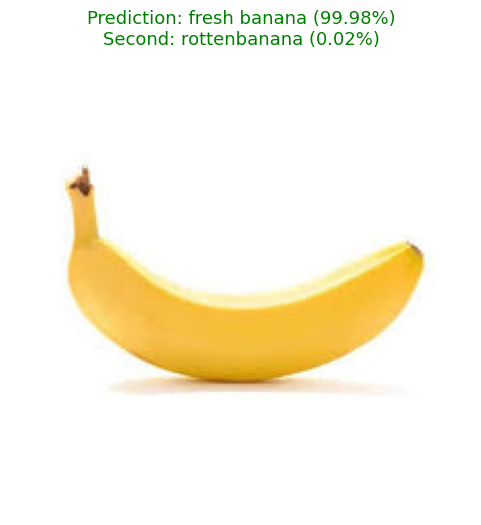

In [44]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

title_text = (
    f"Prediction: {top2_classes[0]} ({top2_confidence[0]:.2f}%)\n"
    f"Second: {top2_classes[1]} ({top2_confidence[1]:.2f}%)"
)

plt.title(title_text, fontsize=13, color="green")
plt.show()
